## El "Divorcio Invisible": ¿Las Uniones de Hecho ocultan la verdadera tasa de ruptura familiar?

Se cree que los departamentos con bajas tasas de divorcio legal poseen una alta tasa de Uniones de Hecho. La hipótesis sugiere que en estas zonas las parejas no se divorcian legalmente porque nunca se casaron, optando por la "separación" informal, lo que generaría un subregistro de rupturas en las estadísticas judiciales.

--- Iniciando Análisis: El Divorcio Invisible (2018) ---

Correlación (Uniones de Hecho vs. Divorcios Legales): -0.0503 (p=0.8242)
Interpretación: No concluyente. (Esperamos negativa)


/tmp/ipykernel_289063/1291743995.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_plot['departamento'], rotation=45, ha='right')


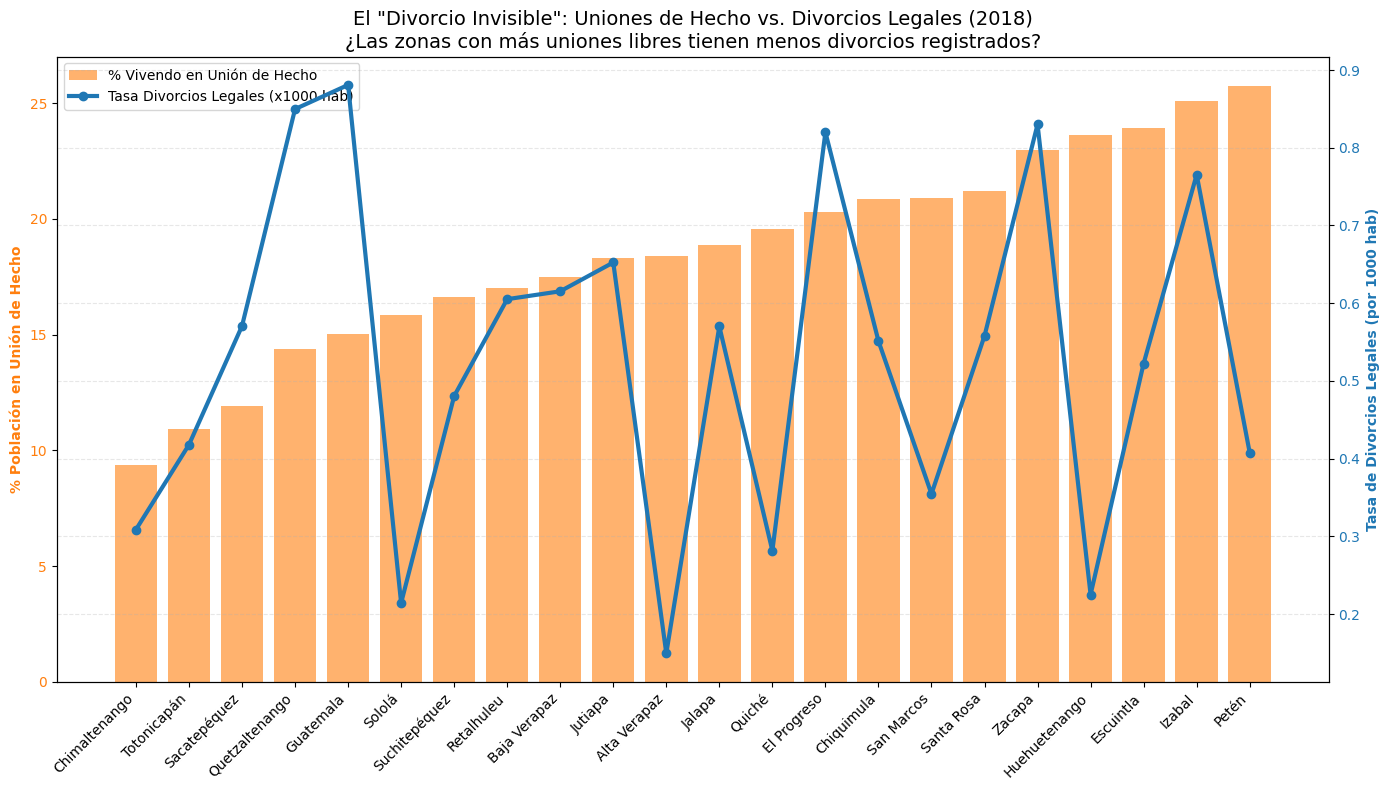


--- Contrastes Extremos ---
Departamentos con MÁS Uniones de Hecho (¿Menos divorcios?):
     departamento  pct_unidos  tasa_divorcio_legal
21         Zacapa   22.966877             0.830004
7   Huehuetenango   23.631981             0.225270
5       Escuintla   23.932590             0.522481
8          Izabal   25.093449             0.765373
11          Petén   25.729308             0.407816

Departamentos con MENOS Uniones de Hecho (¿Más divorcios?):
      departamento  pct_unidos  tasa_divorcio_legal
2    Chimaltenango    9.358588             0.308816
20     Totonicapán   10.932696             0.417999
15    Sacatepéquez   11.934821             0.570634
12  Quetzaltenango   14.362060             0.849742
6        Guatemala   15.032454             0.880776


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

# --- CONFIGURACIÓN ---
project_root = Path.cwd()
while not (project_root / 'data_pipeline.py').exists():
    if project_root.parent == project_root: raise FileNotFoundError("No pipeline found")
    project_root = project_root.parent
if str(project_root) not in sys.path: sys.path.append(str(project_root))
import data_pipeline as dp

print("--- Iniciando Análisis: El Divorcio Invisible (2018) ---")

try:
    # 1. Cargar Divorcios Legales (Panel 2018)
    df_panel = dp.build_panel(force_rebuild=False, only_common_years=False)
    df_divorcios = df_panel[df_panel['anio'] == 2018][['departamento', 'divorcios_total']].copy()

    # 2. Cargar Estado Civil (Censo)
    civil_path = project_root / 'Datos/Poblacion/estado_civil.csv'
    df_civil = pd.read_csv(civil_path)
    
    # Estandarizar nombres
    df_civil.rename(columns={'Departamento': 'departamento', 'Código': 'codigo_depto'}, inplace=True)
    df_civil['departamento'] = df_civil['departamento'].apply(dp._standardize_department)
    
    # 3. Unir Datos
    df_final = pd.merge(df_divorcios, df_civil, on='departamento', how='inner')
    
    # 4. Calcular Indicadores
    # Usamos Población_10_mas como denominador base del estado civil
    pob_base = df_final['Población_10_mas']
    
    # A. Tasa de Divorcio Legal (Eventos del año / Pob) * 1000
    # Nota: Usamos una escala x1000 para que sea comparable visualmente con porcentajes
    df_final['tasa_divorcio_legal'] = (df_final['divorcios_total'] / pob_base) * 1000
    
    # B. Prevalencia de Unión de Hecho (% de la población que vive "juntada")
    df_final['pct_unidos'] = (df_final['Unido'] / pob_base) * 100
    
    # C. Prevalencia de "Divorcio Invisible" (% de Separados en el censo)
    # "Separado" = Ruptura de hecho sin disolución legal (o ruptura de unión libre)
    df_final['pct_separados'] = (df_final['Separado'] / pob_base) * 100

    # 5. Análisis de Correlación
    # Hipótesis: Donde hay más uniones de hecho, hay MENOS divorcios legales.
    coef, p = spearmanr(df_final['pct_unidos'], df_final['tasa_divorcio_legal'])
    print(f"\nCorrelación (Uniones de Hecho vs. Divorcios Legales): {coef:.4f} (p={p:.4f})")
    print(f"Interpretación: {'Validada' if coef < -0.4 else 'No concluyente'}. (Esperamos negativa)")

    # 6. Visualización
    # Ordenamos por % de Uniones de Hecho para ver el patrón "Rural vs Urbano"
    df_plot = df_final.sort_values('pct_unidos', ascending=True)
    
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Eje Izquierdo: Composición de Parejas "Informales"
    ax1.bar(df_plot['departamento'], df_plot['pct_unidos'], color='#ff7f0e', alpha=0.6, label='% Vivendo en Unión de Hecho')
    # Añadimos los separados encima para ver "Ruptura Informal Total" (opcional, o solo unidos)
    # ax1.bar(df_plot['departamento'], df_plot['pct_separados'], bottom=df_plot['pct_unidos'], color='#d62728', alpha=0.6, label='% Separados (No Divorciados)')
    
    ax1.set_ylabel('% Población en Unión de Hecho', color='#ff7f0e', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#ff7f0e')
    ax1.set_xticklabels(df_plot['departamento'], rotation=45, ha='right')

    # Eje Derecho: Tasa de Divorcios Legales
    ax2 = ax1.twinx()
    ax2.plot(df_plot['departamento'], df_plot['tasa_divorcio_legal'], color='#1f77b4', marker='o', linewidth=3, label='Tasa Divorcios Legales (x1000 hab)')
    ax2.set_ylabel('Tasa de Divorcios Legales (por 1000 hab)', color='#1f77b4', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')

    # Título
    plt.title('El "Divorcio Invisible": Uniones de Hecho vs. Divorcios Legales (2018)\n¿Las zonas con más uniones libres tienen menos divorcios registrados?', fontsize=14)
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')
    
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Tabla Top/Bottom para evidencia textual
    print("\n--- Contrastes Extremos ---")
    print("Departamentos con MÁS Uniones de Hecho (¿Menos divorcios?):")
    print(df_plot[['departamento', 'pct_unidos', 'tasa_divorcio_legal']].tail(5))
    print("\nDepartamentos con MENOS Uniones de Hecho (¿Más divorcios?):")
    print(df_plot[['departamento', 'pct_unidos', 'tasa_divorcio_legal']].head(5))

except Exception as e:
    print(f"Error: {e}")